In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('patient.csv')

PHASE 2: DATA CLEANING & PREPROCESSING

In [7]:
# Step 1: Handle missing values
print(df.isnull().sum())  # See where gaps are
# Option A: Drop rows with missing critical info
df_clean = df.dropna(subset=['confirmed_date', 'sex', 'country'])

# Step 2: Convert dates to datetime
df_clean['confirmed_date'] = pd.to_datetime(df_clean['confirmed_date'])
df_clean['released_date'] = pd.to_datetime(df_clean['released_date'])
df_clean['deceased_date'] = pd.to_datetime(df_clean['deceased_date'])

id                     0
sex                 3894
birth_year          3920
country                0
region              3907
group               4136
infection_reason    4082
infection_order     4177
infected_by         4150
contact_number      4180
confirmed_date         0
released_date       4184
deceased_date       4199
state                  0
dtype: int64


C:\Users\swaya\AppData\Local\Temp\ipykernel_15688\3200723549.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['confirmed_date'] = pd.to_datetime(df_clean['confirmed_date'])
C:\Users\swaya\AppData\Local\Temp\ipykernel_15688\3200723549.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['released_date'] = pd.to_datetime(df_clean['released_date'])
C:\Users\swaya\AppData\Local\Temp\ipykernel_15688\3200723549.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice fro

In [8]:
# Step 3: Calculate recovery duration
# For released patients: released_date - confirmed_date
# For deceased patients: deceased_date - confirmed_date
df_clean['recovery_days'] = np.where(
    df_clean['state'] == 'released',
    (df_clean['released_date'] - df_clean['confirmed_date']).dt.days,
    (df_clean['deceased_date'] - df_clean['confirmed_date']).dt.days
)

# Step 4: Calculate age
current_year = 2020  # Adjust based on your data year
df_clean['age'] = current_year - df_clean['birth_year']

# Step 5: Check for duplicates
print(df_clean.duplicated().sum())
df_clean = df_clean.drop_duplicates()

print(df_clean.info())
print(df_clean.head())

0
<class 'pandas.core.frame.DataFrame'>
Index: 318 entries, 0 to 2640
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   id                318 non-null    int64         
 1   sex               318 non-null    object        
 2   birth_year        292 non-null    float64       
 3   country           318 non-null    object        
 4   region            297 non-null    object        
 5   group             74 non-null     object        
 6   infection_reason  127 non-null    object        
 7   infection_order   34 non-null     float64       
 8   infected_by       60 non-null     float64       
 9   contact_number    32 non-null     float64       
 10  confirmed_date    318 non-null    datetime64[ns]
 11  released_date     28 non-null     datetime64[ns]
 12  deceased_date     13 non-null     datetime64[ns]
 13  state             318 non-null    object        
 14  recovery_days     41 non-nul

C:\Users\swaya\AppData\Local\Temp\ipykernel_15688\2651618763.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['recovery_days'] = np.where(
C:\Users\swaya\AppData\Local\Temp\ipykernel_15688\2651618763.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['age'] = current_year - df_clean['birth_year']


PHASE 3: EXPLORATORY DATA ANALYSIS (EDA)

In [9]:
# Descriptive Statistics
print("\n=== DEMOGRAPHIC SUMMARY ===")
print(f"Total Patients: {len(df_clean)}")
print(f"Average Age: {df_clean['age'].mean():.1f} years")
print(f"Age Range: {df_clean['age'].min()}-{df_clean['age'].max()} years")

# Gender Distribution
print("\n=== GENDER DISTRIBUTION ===")
print(df_clean['sex'].value_counts())
print(df_clean['sex'].value_counts(normalize=True) * 100)  # Percentages

# Regional Distribution
print("\n=== CASES BY REGION ===")
print(df_clean['region'].value_counts())

# Country Distribution
print("\n=== CASES BY COUNTRY ===")
print(df_clean['country'].value_counts())

# Infection Reason
print("\n=== INFECTION SOURCES ===")
print(df_clean['infection_reason'].value_counts())

# Case Outcomes
print("\n=== CASE OUTCOMES ===")
print(df_clean['state'].value_counts())

# Infection Order Statistics
print("\n=== INFECTION ORDER ===")
print(f"Average infection order: {df_clean['infection_order'].mean():.2f}")
print(df_clean['infection_order'].value_counts().head(10))

# Contact Number Statistics
print("\n=== CONTACT EXPOSURE ===")
print(f"Average contacts: {df_clean['contact_number'].mean():.1f}")
print(f"Max contacts: {df_clean['contact_number'].max()}")

# Recovery Statistics
print("\n=== RECOVERY DURATION ===")
recovery_data = df_clean[df_clean['state'] == 'released']
print(f"Average recovery time: {recovery_data['recovery_days'].mean():.1f} days")
print(f"Median recovery time: {recovery_data['recovery_days'].median():.1f} days")
print(f"Min-Max: {recovery_data['recovery_days'].min()}-{recovery_data['recovery_days'].max()} days")


=== DEMOGRAPHIC SUMMARY ===
Total Patients: 318
Average Age: 46.8 years
Age Range: 2.0-83.0 years

=== GENDER DISTRIBUTION ===
sex
female    163
male      155
Name: count, dtype: int64
sex
female    51.257862
male      48.742138
Name: proportion, dtype: float64

=== CASES BY REGION ===
region
Gyeongsangbuk-do       113
capital area           107
Daegu                   34
Gwangju                 10
Daejeon                 10
Gangwon-do               5
filtered at airport      4
Jeollabuk-do             4
Jeju-do                  2
Busan                    2
Chungcheongbuk-do        2
Chungcheongnam-do        2
Ulsan                    2
Name: count, dtype: int64

=== CASES BY COUNTRY ===
country
Korea       309
China         8
Mongolia      1
Name: count, dtype: int64

=== INFECTION SOURCES ===
infection_reason
contact with patient                 64
visit to Daegu                       39
visit to Wuhan                        8
pilgrimage to Israel                  6
residence in Wuh

PHASE 4: DATA VISUALIZATION

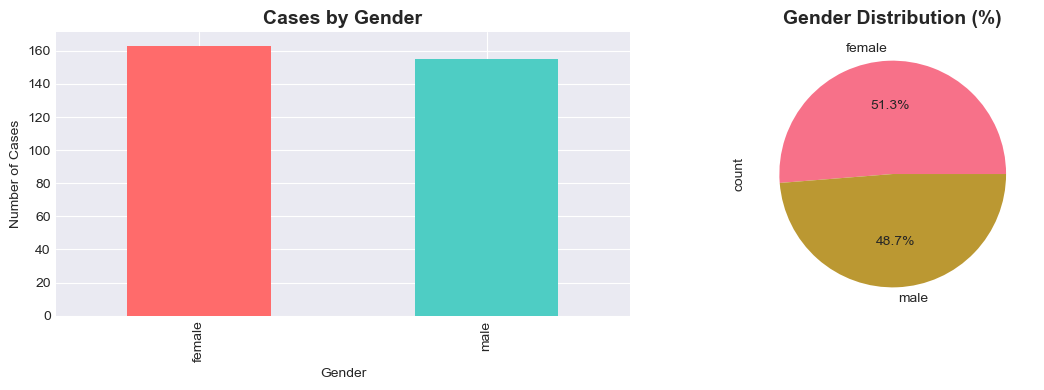

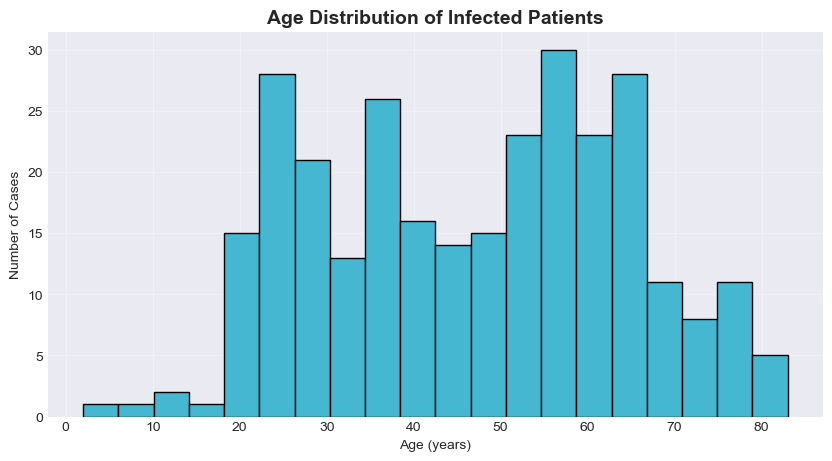

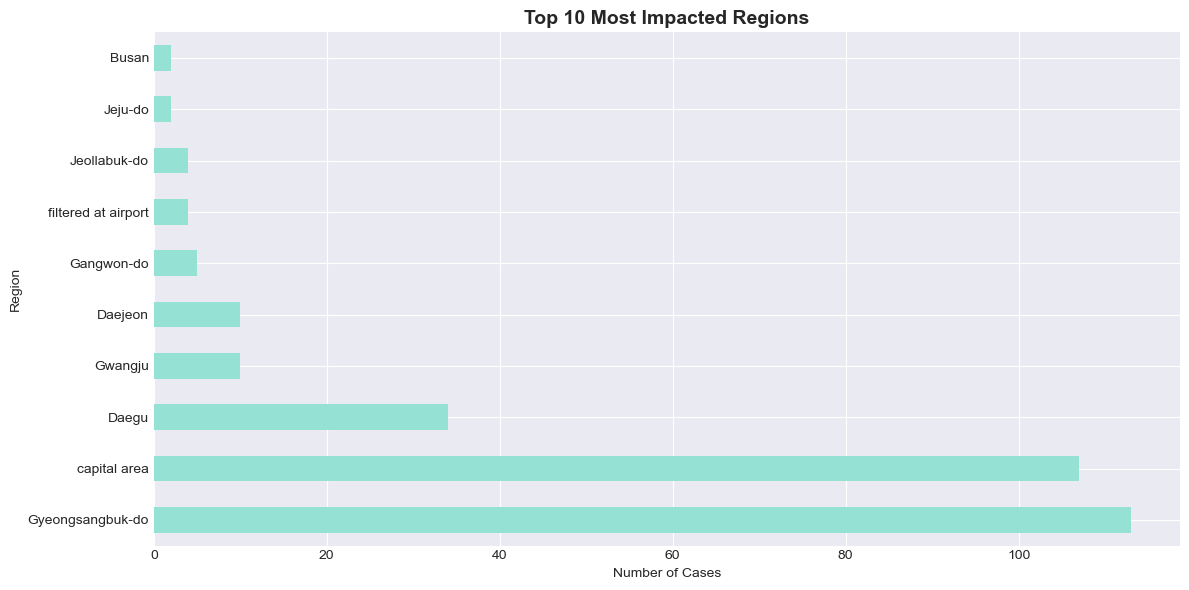

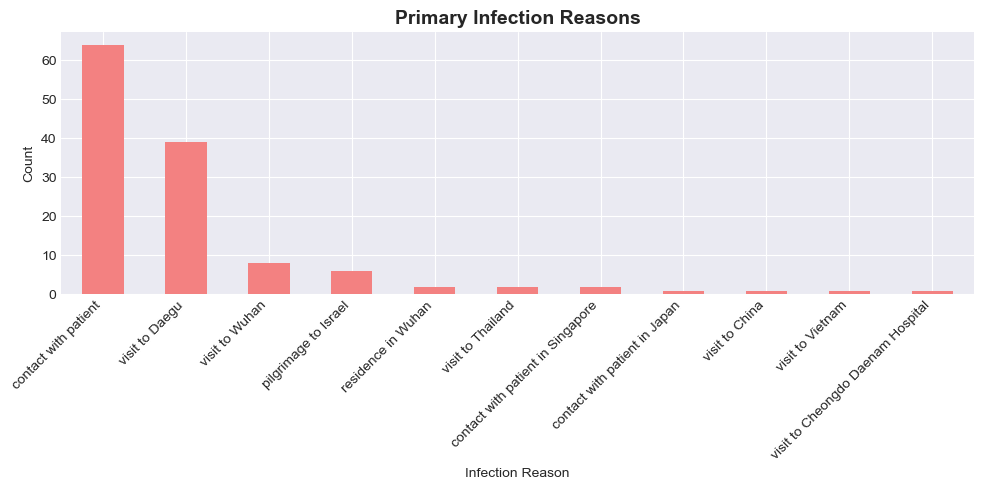

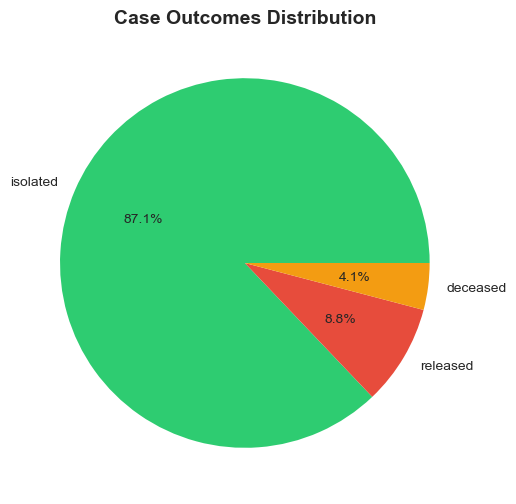

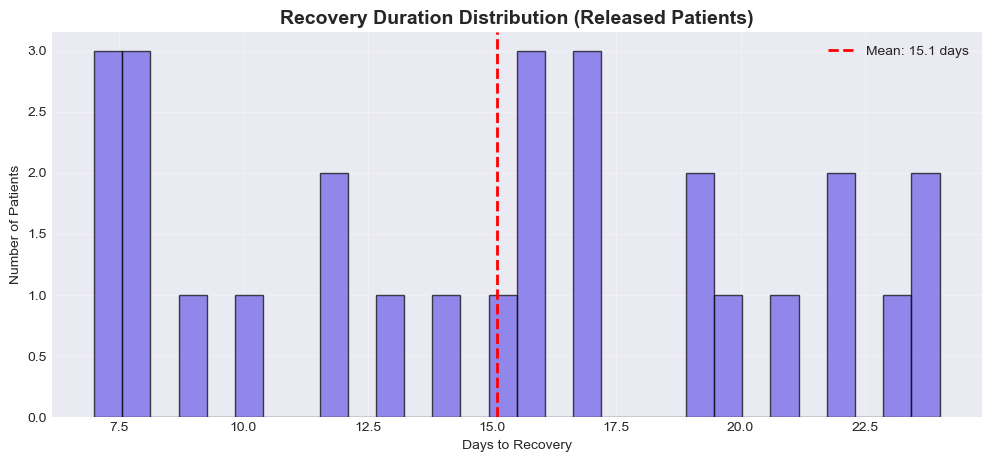

<Figure size 1400x600 with 0 Axes>

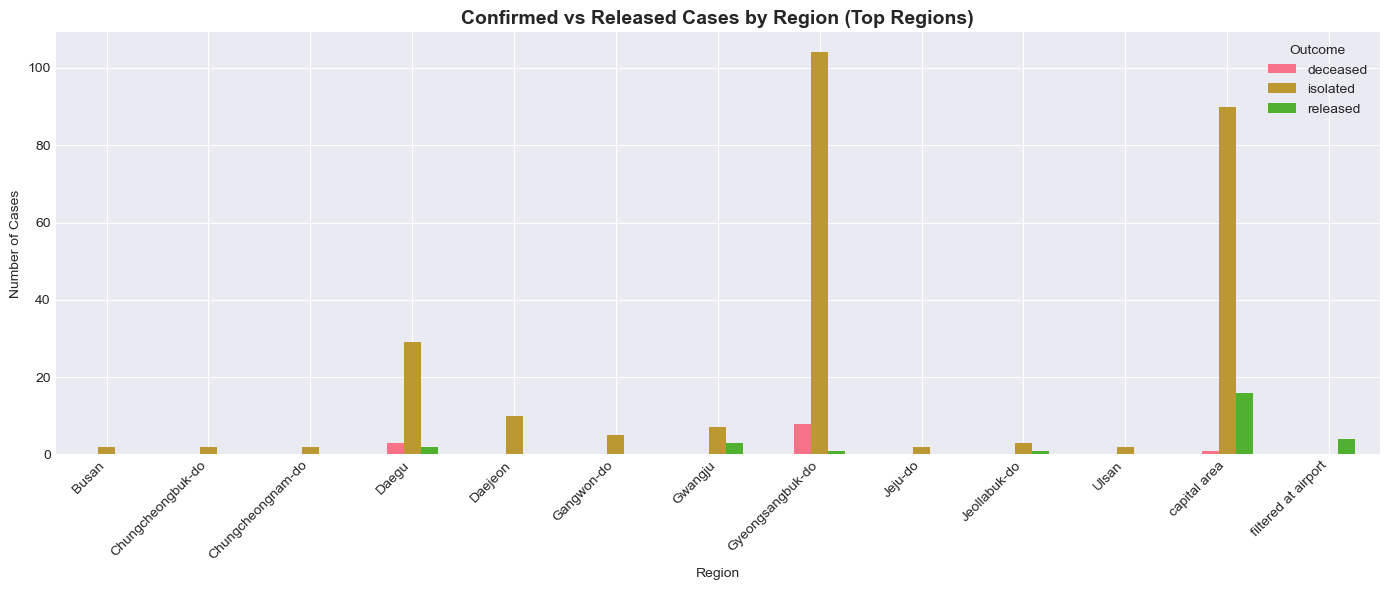

In [10]:
# Set up the plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# 1. Gender Distribution
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
df_clean['sex'].value_counts().plot(kind='bar', ax=ax[0], color=['#FF6B6B', '#4ECDC4'])
ax[0].set_title('Cases by Gender', fontsize=14, fontweight='bold')
ax[0].set_ylabel('Number of Cases')
ax[0].set_xlabel('Gender')

df_clean['sex'].value_counts().plot(kind='pie', ax=ax[1], autopct='%1.1f%%')
ax[1].set_title('Gender Distribution (%)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 2. Age Distribution
plt.figure(figsize=(10, 5))
plt.hist(df_clean['age'], bins=20, color='#45B7D1', edgecolor='black')
plt.title('Age Distribution of Infected Patients', fontsize=14, fontweight='bold')
plt.xlabel('Age (years)')
plt.ylabel('Number of Cases')
plt.grid(True, alpha=0.3)
plt.show()

# 3. Regional Case Concentration
plt.figure(figsize=(12, 6))
region_counts = df_clean['region'].value_counts().head(10)
region_counts.plot(kind='barh', color='#95E1D3')
plt.title('Top 10 Most Impacted Regions', fontsize=14, fontweight='bold')
plt.xlabel('Number of Cases')
plt.ylabel('Region')
plt.tight_layout()
plt.show()

# 4. Infection Sources
plt.figure(figsize=(10, 5))
infection_source = df_clean['infection_reason'].value_counts()
infection_source.plot(kind='bar', color='#F38181')
plt.title('Primary Infection Reasons', fontsize=14, fontweight='bold')
plt.xlabel('Infection Reason')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 5. Case Outcomes
plt.figure(figsize=(10, 6))
outcomes = df_clean['state'].value_counts()
colors = ['#2ECC71', '#E74C3C', '#F39C12']
outcomes.plot(kind='pie', autopct='%1.1f%%', colors=colors)
plt.title('Case Outcomes Distribution', fontsize=14, fontweight='bold')
plt.ylabel('')
plt.show()

# 6. Recovery Timeline (for released patients only)
plt.figure(figsize=(12, 5))
released = df_clean[df_clean['state'] == 'released']
plt.hist(released['recovery_days'], bins=30, color='#6C5CE7', edgecolor='black', alpha=0.7)
plt.title('Recovery Duration Distribution (Released Patients)', fontsize=14, fontweight='bold')
plt.xlabel('Days to Recovery')
plt.ylabel('Number of Patients')
plt.axvline(released['recovery_days'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {released["recovery_days"].mean():.1f} days')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 7. Regional Comparison (Confirmed vs Released)
plt.figure(figsize=(14, 6))
regional_outcomes = pd.crosstab(df_clean['region'], df_clean['state'])
regional_outcomes.plot(kind='bar', figsize=(14, 6))
plt.title('Confirmed vs Released Cases by Region (Top Regions)', fontsize=14, fontweight='bold')
plt.xlabel('Region')
plt.ylabel('Number of Cases')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Outcome')
plt.tight_layout()
plt.show()

PHASE 5: CORRELATION & STATISTICAL ANALYSIS


=== CORRELATION MATRIX ===
                      age  infection_order  contact_number  recovery_days
age              1.000000        -0.075645        0.174319       0.106142
infection_order -0.075645         1.000000       -0.180797       0.018192
contact_number   0.174319        -0.180797        1.000000      -0.244144
recovery_days    0.106142         0.018192       -0.244144       1.000000


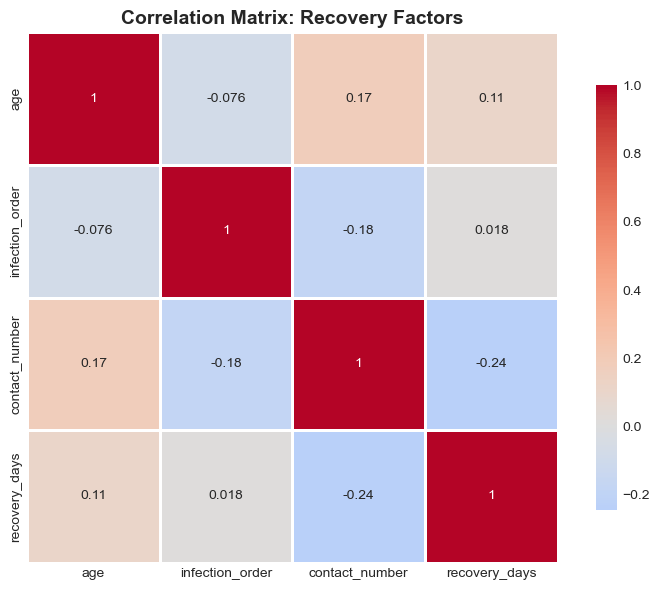

C:\Users\swaya\AppData\Local\Temp\ipykernel_15688\3294714205.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_recovery = df_clean[df_clean['state'] == 'released'].groupby('age_group')['recovery_days'].mean()


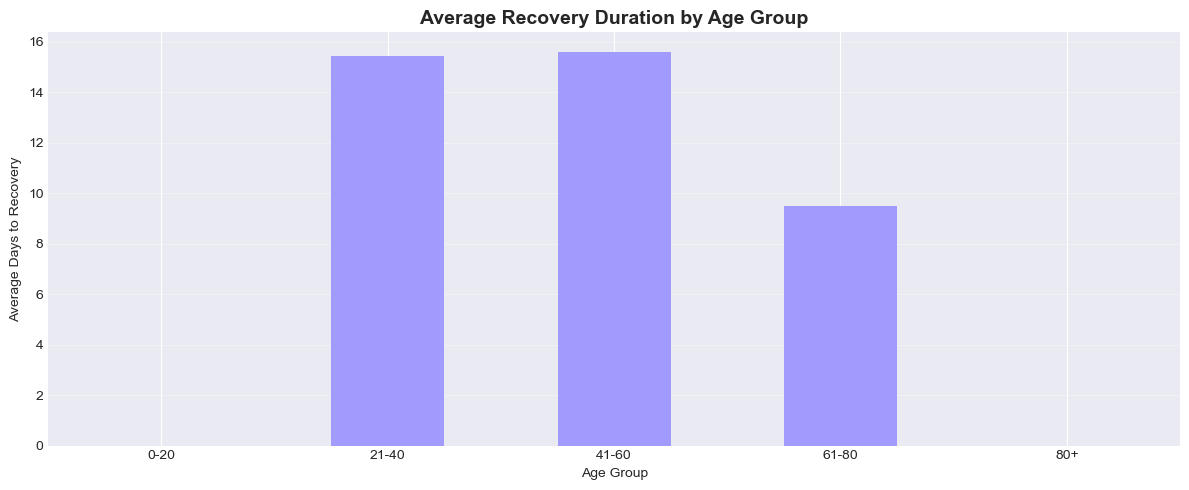

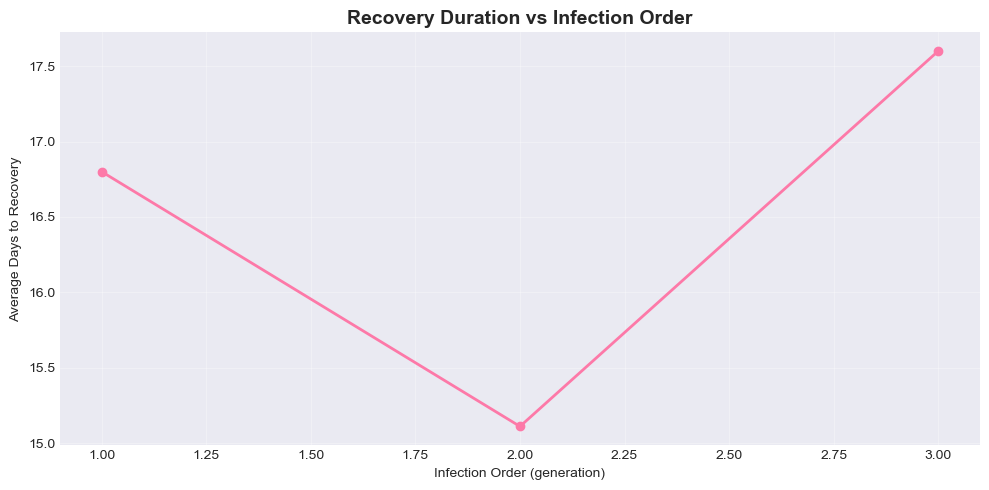

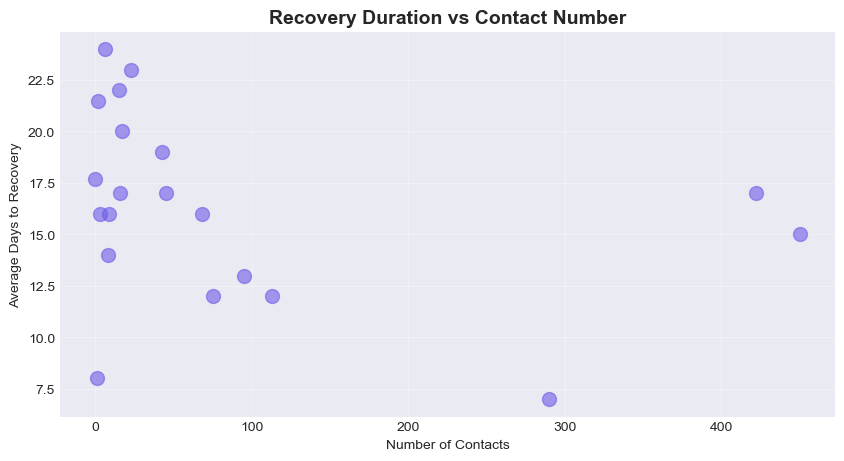

In [11]:
# Step 1: Select numeric columns for correlation
numeric_cols = ['age', 'infection_order', 'contact_number', 'recovery_days']
df_numeric = df_clean[numeric_cols].dropna()

# Step 2: Calculate correlation matrix
correlation_matrix = df_numeric.corr()
print("\n=== CORRELATION MATRIX ===")
print(correlation_matrix)

# Step 3: Visualize correlations
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix: Recovery Factors', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Step 4: Specific analysis - Recovery by Age Groups
plt.figure(figsize=(12, 5))
df_clean['age_group'] = pd.cut(df_clean['age'], bins=[0, 20, 40, 60, 80, 100], 
                                labels=['0-20', '21-40', '41-60', '61-80', '80+'])
age_recovery = df_clean[df_clean['state'] == 'released'].groupby('age_group')['recovery_days'].mean()
age_recovery.plot(kind='bar', color='#A29BFE')
plt.title('Average Recovery Duration by Age Group', fontsize=14, fontweight='bold')
plt.xlabel('Age Group')
plt.ylabel('Average Days to Recovery')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Step 5: Recovery by Infection Order
plt.figure(figsize=(10, 5))
infection_recovery = df_clean[df_clean['state'] == 'released'].groupby('infection_order')['recovery_days'].mean().head(10)
infection_recovery.plot(kind='line', marker='o', color='#FD79A8', linewidth=2)
plt.title('Recovery Duration vs Infection Order', fontsize=14, fontweight='bold')
plt.xlabel('Infection Order (generation)')
plt.ylabel('Average Days to Recovery')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Step 6: Recovery by Contact Number
plt.figure(figsize=(10, 5))
contact_recovery = df_clean[df_clean['state'] == 'released'].groupby('contact_number')['recovery_days'].mean()
plt.scatter(contact_recovery.index, contact_recovery.values, alpha=0.6, s=100, color='#6C5CE7')
plt.title('Recovery Duration vs Contact Number', fontsize=14, fontweight='bold')
plt.xlabel('Number of Contacts')
plt.ylabel('Average Days to Recovery')
plt.grid(True, alpha=0.3)
plt.show()

PHASE 6: LINEAR REGRESSION MODELING


=== MODEL EVALUATION ===
R² Score: -0.6577
RMSE: 3.40 days

Coefficients:
  age: 0.0788
  infection_order: 0.0213
  contact_number: -0.0092
Intercept: 13.10


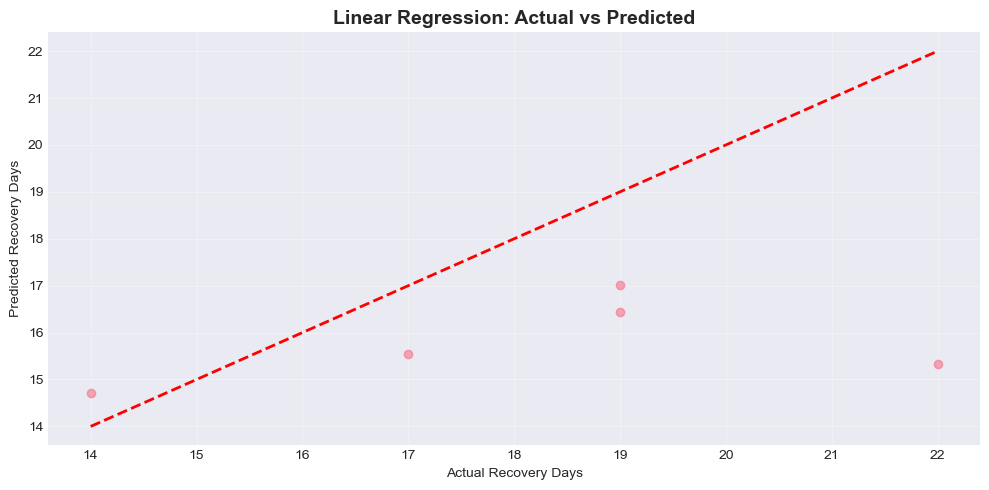

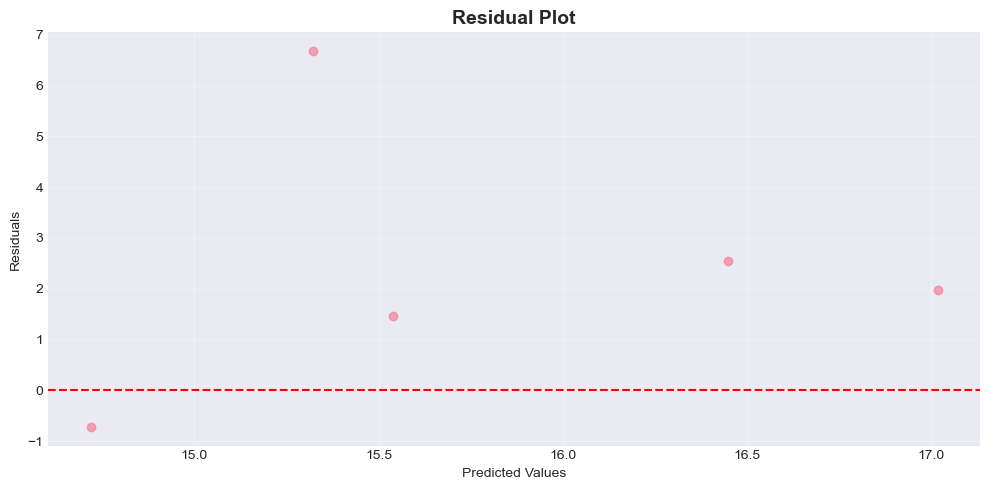

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# Prepare data
recovery_df = df_clean[df_clean['state'] == 'released'].copy()
recovery_df = recovery_df[['age', 'infection_order', 'contact_number', 'recovery_days']].dropna()

# Features and Target
X = recovery_df[['age', 'infection_order', 'contact_number']]
y = recovery_df['recovery_days']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build and train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluate
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\n=== MODEL EVALUATION ===")
print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.2f} days")
print(f"\nCoefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"  {feature}: {coef:.4f}")
print(f"Intercept: {model.intercept_:.2f}")

# Visualize Predictions vs Actual
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Recovery Days')
plt.ylabel('Predicted Recovery Days')
plt.title('Linear Regression: Actual vs Predicted', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Residual Analysis
residuals = y_test - y_pred
plt.figure(figsize=(10, 5))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()